In [1]:
import sys
sys.path.append('../GC_stream')

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from astropy.io import fits
import astropy.units as u
from ezpadova import parsec

import stream_dataset as sd
import GC

In [2]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)

<module 'GC' from '/Users/ybchen/Documents/GC_stream/notebooks/../GC_stream/GC.py'>

In [3]:
G_limit = 19

In [4]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

In [5]:
# Detect segments from streams

def detect_segs(stream, width=None, gap_angle=10, percentiles=[10,90], min_count=10):
    angle_tid = stream.prog['rt'] / stream.prog['Rsun'] * 1e-3 * 180 / np.pi
    if width is None:
        width = np.sqrt(np.mean(stream.phi2hat**2))
    segs = []
    if stream.prog_phi2hat < width and stream.prog_phi2hat > -width:
        maskl = (stream.phi1 < stream.prog_phi1 - angle_tid) 
        maskr = (stream.phi1 > stream.prog_phi1 + angle_tid)
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskl]), gap_angle, percentiles, min_count))
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskr]), gap_angle, percentiles, min_count))
    else:
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1), gap_angle, percentiles, min_count))
    return segs

def detect_gaps_in_arms(phi1_arm, gap_angle=10, percentiles=[10,90], min_count=10):
    cuts = [-np.inf]
    for i in range(len(phi1_arm)-1):
        if phi1_arm[i+1] - phi1_arm[i] >= gap_angle:
            cuts.append((phi1_arm[i+1] + phi1_arm[i])/2)
    cuts.append(np.inf)
    
    segs = []
    for i in range(len(cuts)-1):
        mask = (phi1_arm > cuts[i]) & (phi1_arm <= cuts[i+1])
        seg = np.percentile(phi1_arm[mask], percentiles)
        segs.append(seg)
        if len(phi1_arm[mask]) < min_count:
            continue
    return segs

In [6]:
# calculate Gaussian width for segments

def calc_selection_function(stream, segs):
    gaussian_widths = []
    for seg in segs:
        mask = (stream.phi1 > seg[0]) & (stream.phi1 <= seg[1])
        gaussian_widths.append(calc_gaussian_width_seg(stream.phi2hat[mask]))
    return gaussian_widths

def calc_gaussian_width_seg(seg_phi2hat):
    return np.sqrt(np.mean(seg_phi2hat**2))

In [7]:
# load GC info as pandas dataframe
gc = GC.load_GC()

# use Koposov+17 for Pal 5
gc.at['Pal_5', 'RA'] = 229
gc.at['Pal_5', 'DEC'] = -0.111
gc.at['Pal_5', 'RSun'] = 23.6
gc.at['Pal_5', 'mu_alpha'] = -2.23
gc.at['Pal_5', 'mu_delta'] = -2.22
gc.at['Pal_5', '<RV>'] = -57.4

In [8]:
# load Ibata+24
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)

gc_stream_list = ['Pal_5'] # test case
gc_stream_ids = np.array([61], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

1it [00:02,  2.32s/it]


Interrogating http://stev.oapd.inaf.it...


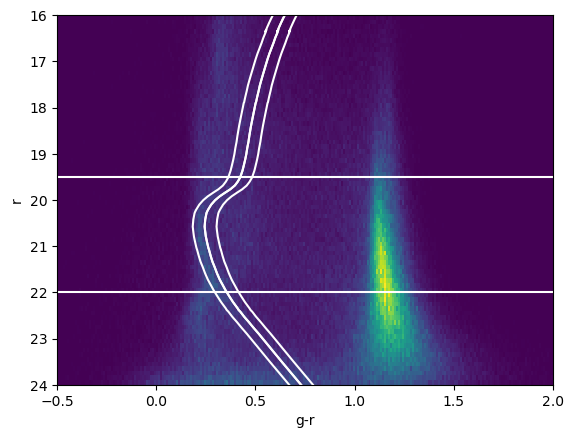

In [9]:
# load Ibata+19
hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
data = hdul[1].data
hdul.close()

plt.hist2d(data['g0mag']-data['r0mag'], data['r0mag'], bins=(np.arange(-0.5,2.01,0.01), np.arange(16,24.1,0.1)))#, norm=mpl.colors.LogNorm())

# apply CMD mask
iso = parsec.get_one_isochrone(1.25e10,10.0**gc.loc['Pal_5'].feh*0.0152,model='parsec12s_r14',phot='megacam_wircam')
mask = iso['label'] <= 3
x = iso["g'mag"][mask]-iso["r'mag"][mask]
y = iso["r'mag"][mask]+16.6
interp = interp1d(y, x, bounds_error=False, fill_value=999)

plt.plot(x+0.03, y, c='w')
plt.plot(x-0.03, y, c='w')
plt.hlines([19.5, 22], -0.5, 2.0, color='w')

mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])-0.03)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+0.03)
mask &= (data['r0mag'] < 22)
mask &= (data['r0mag'] > 19.5)

ds_i19 = {}
ds_i19['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

# Now, the background
mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])+0.03)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+0.09)
mask &= (data['r0mag'] < 22)
mask &= (data['r0mag'] > 19.5)

plt.plot(x+0.03, y, c='w')
plt.plot(x+0.09, y, c='w')

ds_i19_bg = {}
ds_i19_bg['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

plt.ylim(24,16)
plt.xlabel('g-r')
plt.ylabel('r')
plt.show()

In [10]:
ds_i19['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)
ds_i19_bg['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19_bg['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [11]:
ds_i19['Pal_5'].apply_mask((ds_i19['Pal_5'].phi1<14) & (ds_i19['Pal_5'].phi1>-14))
ds_i19_bg['Pal_5'].apply_mask((ds_i19_bg['Pal_5'].phi1<14) & (ds_i19_bg['Pal_5'].phi1>-14))

(-2.0, 2.0)

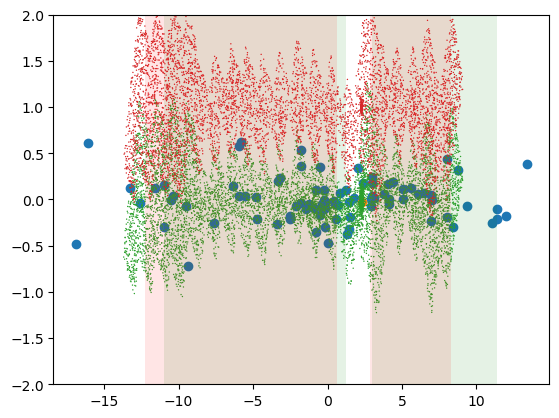

In [12]:
plt.scatter(ds_i24['Pal_5'].phi1, ds_i24['Pal_5'].phi2hat)
plt.scatter(ds_i24['Pal_5'].prog_phi1, ds_i24['Pal_5'].prog_phi2hat)
segs = detect_segs(ds_i24['Pal_5'])
for seg in segs:
    plt.fill_betweenx([-2,2], [seg[0],seg[0]], [seg[1],seg[1]], fc='g', ec='none', alpha=0.1)

plt.scatter(ds_i19['Pal_5'].phi1, ds_i19['Pal_5'].phi2hat, s=1, ec='none')
plt.scatter(ds_i19_bg['Pal_5'].phi1, ds_i19_bg['Pal_5'].phi2hat+1, s=1, ec='none')
segs = detect_segs(ds_i19['Pal_5'])
for seg in segs:
    plt.fill_betweenx([-2,2], [seg[0],seg[0]], [seg[1],seg[1]], fc='r', ec='none', alpha=0.1)

# plt.xlim(-15,15)
plt.ylim(-2,2)

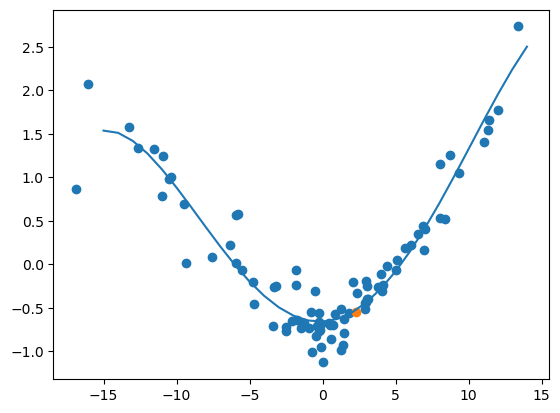

In [14]:
plt.scatter(ds_i24['Pal_5'].phi1, ds_i24['Pal_5'].phi2)
plt.scatter(ds_i24['Pal_5'].prog_phi1, ds_i24['Pal_5'].prog_phi2)

x = np.arange(-15,15,1)
plt.plot(x, ds_i24['Pal_5'].fit_poly(x))

In [15]:
# load Ibata+24
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)

gc_stream_list = ['NGC_5139'] # test case
gc_stream_ids = np.array([54], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

1it [00:04,  4.27s/it]


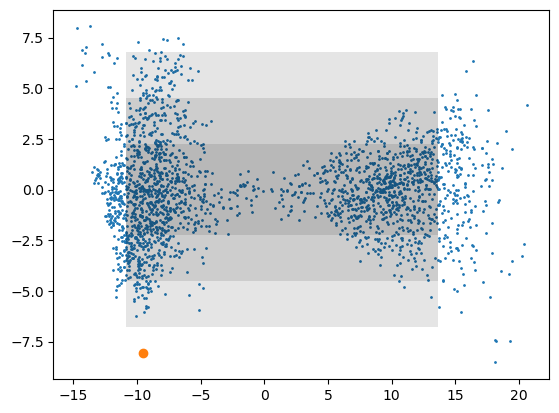

In [16]:
key = 'NGC_5139'
plt.scatter(ds_i24[key].phi1, ds_i24[key].phi2hat, s=1)
plt.scatter(ds_i24[key].prog_phi1, ds_i24[key].prog_phi2hat)
segs = detect_segs(ds_i24[key])

gaus_widths = calc_selection_function(ds_i24[key], segs)
for seg, width in zip(segs, gaus_widths):
    for factor in [1,2,3]:
        plt.fill_between(seg, [-factor*width,-factor*width], [factor*width,factor*width], fc='k', ec='none', alpha=0.1)

# plt.xlim(-10,10)
# plt.ylim(-5,5)